In [2]:
import arviz as az
import math
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import scipy.stats as stats
import pandas as pd
import rethinking as rt
import warnings
import xarray as xr
from causalgraphicalmodels import CausalGraphicalModel

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
hdi_fill_args = { 'color': 'gray', 'alpha': 0.2 }

__Probabilistic Programming. Wasowski. Pardo. IT University of Copenhagen__

This file contains the list of exercises for the week, as well as any related code.

## Exercises

## Exercise 8E1

For each of the causal relationships below, name a hypothetical third variable that would lead
to an interaction effect.
(1) Bread dough rises because of yeast.
(2) Education leads to higher income.
(3) Gasoline makes a car go.

## answers

(1) Bread dough rising and yeast could have a third variable like water, temperature, time, sugar, salt.
(2) Education and higher income could have a third variable like social status, family background, intelligence, motivation.
(3) Gasoline and car going could have a third variable like engine, driver, road, weather, traffic, air pressure, oxygen proportion.

## Exercise 8M1

This is a discussion exercise. Nothing to write, nothing to hand in.

## Exercise 8M2

Solve with pen and pelcin, or in LaTeX below.

$$
\mu = \beta_1 \cdot Water \cdot Shade \cdot Temperature
$$

## Exercise 8M4

Modify the model `m_8_5` included in the lecture. Here is a copy of that model for your convenience:

In [30]:
d = pd.read_csv("tulips.csv", delimiter=";").to_xarray()
d["blooms_std"] = d.blooms / d.blooms.max()
d["water_cent"] = d.water - d.water.mean()
d["shade_cent"] = d.shade - d.shade.mean()

with pm.Model() as m_8_5:
    a = pm.Normal("a", 0.5, 0.25)
    bw = pm.TruncatedNormal("bw", mu=0.25, sigma=0.1, lower=0)  # Positive effect of water
    bs = pm.TruncatedNormal("bs", mu=-0.25, sigma=0.1, upper=0)  # Negative effect of shade
    bws = pm.Normal("bws", 0, 0.25)

    mu = pm.Deterministic("mu", 
         a +  bw * d.water_cent.values \
           +  bs * d.shade_cent.values \
           + bws * d.water_cent.values * d.shade_cent.values)
    sigma = pm.Exponential("sigma", 1)

    blooms_std = pm.Normal("blooms_std", mu, sigma, observed = d.blooms_std.values)

    # Prior predictive checks
    prior_pred = pm.sample_prior_predictive()

    m_8_5_idata = pm.sample(random_seed = rng, idata_kwargs={"log_likelihood": True})

Sampling: [a, blooms_std, bs, bw, bws, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, bw, bs, bws, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 37 seconds.


In [7]:
az.summary(m_8_5_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.359,0.028,0.307,0.413,0.000,0.000,3711.0,2809.0,1.0
bws,-0.142,0.041,-0.219,-0.063,0.001,0.000,4367.0,2653.0,1.0
bw,0.215,0.032,0.154,0.275,0.000,0.000,4140.0,2482.0,1.0
bs,-0.129,0.031,-0.190,-0.072,0.001,0.000,3178.0,1894.0,1.0
sigma,0.143,0.022,0.106,0.185,0.000,0.000,3044.0,2887.0,1.0
mu[0],0.131,0.065,0.008,0.253,0.001,0.001,3979.0,3259.0,1.0
mu[1],0.144,0.043,0.060,0.219,0.001,0.000,4207.0,2844.0,1.0
mu[2],0.158,0.069,0.026,0.287,0.001,0.001,3673.0,2924.0,1.0
mu[3],0.488,0.042,0.413,0.569,0.001,0.000,3784.0,2706.0,1.0
mu[4],0.359,0.028,0.307,0.413,0.000,0.000,3711.0,2809.0,1.0


It seems like the

## Exercise 8H1

The code to load the data is in the lecture; modify model `m_8_5` as included above. To quickly analyze the results of the posterior inference, use `arviz.summary`. Is there a difference between the three beds?

In [28]:
d = pd.read_csv("tulips.csv", delimiter=";").to_xarray()
d["blooms_std"] = d.blooms / d.blooms.max()
d["water_cent"] = d.water - d.water.mean()
d["shade_cent"] = d.shade - d.shade.mean()
# d["bed"] = pd.factorize(d.bed)[0]

bed_codes, bed_mapping = pd.factorize(d.bed)  # Converts "a", "b", "c" into 0, 1, 2
d["bed_code"] = bed_codes

with pm.Model() as m_8_5_bed:
    a = pm.Normal("a", 0.5, 0.25)
    bw = pm.TruncatedNormal("bw", mu=0.25, sigma=0.1, lower=0)  # Positive effect of water
    bs = pm.TruncatedNormal("bs", mu=-0.25, sigma=0.1, upper=0)  # Negative effect of shade
    bws = pm.Normal("bws", 0, 0.25)
    bb = pm.Normal("bb", 0, 0.25, shape=bed_mapping.size)

    mu = pm.Deterministic("mu", 
         a +  bw * d.water_cent.values \
           +  bs * d.shade_cent.values \
           + bws * d.water_cent.values * d.shade_cent.values
           + bb[d.bed_code.values])
    sigma = pm.Exponential("sigma", 1)

    blooms_std = pm.Normal("blooms_std", mu, sigma, observed = d.blooms_std.values)

    # Prior predictive checks
    prior_pred = pm.sample_prior_predictive()

    m_8_5_bed_idata = pm.sample(random_seed = rng, idata_kwargs={"log_likelihood": True})

C:\Users\patr7\AppData\Local\Temp\ipykernel_23600\44656265.py:7: FutureWarning: factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  bed_codes, bed_mapping = pd.factorize(d.bed)  # Converts "a", "b", "c" into 0, 1, 2
Sampling: [a, bb, blooms_std, bs, bw, bws, sigma]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [a, bw, bs, bws, bb, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 44 seconds.


In [24]:
az.summary(m_8_5_bed_idata)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a,0.393,0.126,0.166,0.634,0.004,0.003,932.0,1313.0,1.0
bws,-0.142,0.038,-0.212,-0.067,0.001,0.000,3684.0,2301.0,1.0
bb[0],-0.120,0.129,-0.366,0.118,0.004,0.003,999.0,1481.0,1.0
bb[1],0.002,0.130,-0.244,0.235,0.004,0.003,1006.0,1575.0,1.0
bb[2],0.014,0.130,-0.238,0.248,0.004,0.003,959.0,1437.0,1.0
bw,0.212,0.030,0.156,0.269,0.001,0.000,2682.0,1754.0,1.0
bs,-0.127,0.031,-0.186,-0.070,0.001,0.000,2769.0,2130.0,1.0
sigma,0.131,0.022,0.093,0.172,0.000,0.000,2520.0,2178.0,1.0
mu[0],0.045,0.072,-0.089,0.188,0.001,0.001,3440.0,3112.0,1.0
mu[1],0.061,0.053,-0.039,0.159,0.001,0.001,3351.0,3035.0,1.0


array([<Axes: title={'center': '95.0% HDI'}>], dtype=object)

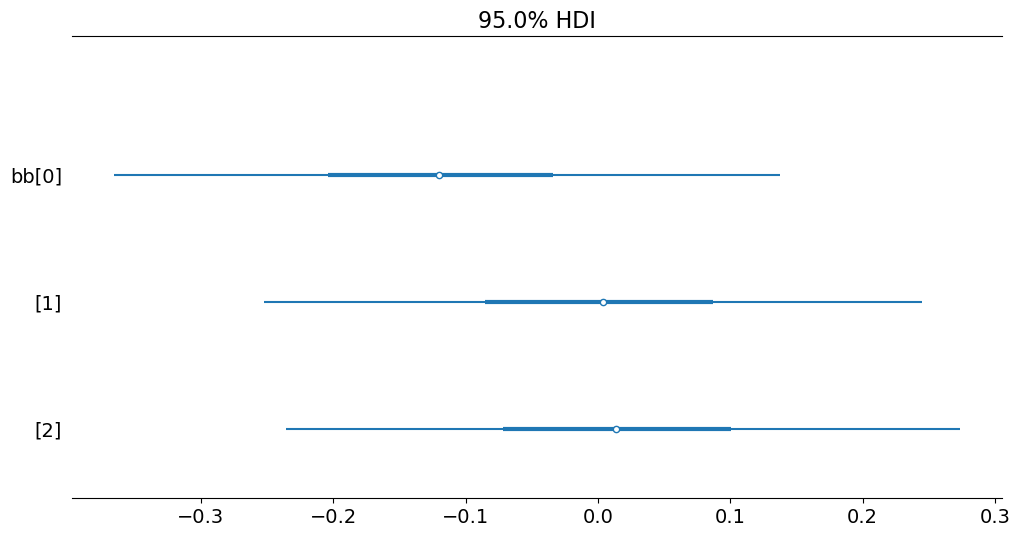

In [25]:
az.plot_forest(m_8_5_bed_idata, var_names=["bb"], combined=True, hdi_prob=0.95, figsize=(12, 6))

## Exercise 8H2

`arivz.compare` (As used in the lecture on interactions) can also compute WAIC (https://arviz-devs.github.io/arviz/api/generated/arviz.compare.html).  There is also a dedicated WAIC function: https://arviz-devs.github.io/arviz/api/generated/arviz.waic.html
* skip __8H3__

In [31]:
az.compare({ "m_8_5": m_8_5_idata, "m_8_5_bed": m_8_5_bed_idata }, ic="waic")

c:\Users\patr7\miniconda3\envs\prpro-2025\Lib\site-packages\arviz\stats\stats.py:1653: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
c:\Users\patr7\miniconda3\envs\prpro-2025\Lib\site-packages\arviz\stats\stats.py:1653: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
m_8_5_bed,0,13.791236,6.119470,0.000000,0.704673,3.400612,0.000000,True,log
m_8_5,1,12.515038,4.289589,1.276197,0.295327,3.858013,2.768564,True,log


## Exercise 8H4 or 8H5 

Solve one of __8H4__ or __8H5__.  The exercise __8H4__ resembles a possible exam problem (this is roughly the level at which we are aiming for the exam projects). 

The values in data(nettle) are data on language diversity in 74 nations. The meaning of each column is given below.

(1) country: Name of the country
(2) num.lang: Number of recognized languages spoken
(3) area: Area in square kilometers
(4) k.pop: Population, in thousands
(5) num.stations: Number of weather stations that provided data for the next two columns
(6) mean.growing.season: Average length of growing season, in months
(7) sd.growing.season: Standard deviation of length of growing season, in months

Use these data to evaluate the hypothesis that language diversity is partly a product of food security. The notion is that, in productive ecologies, people don’t need large social networks to buffer them against risk of food shortfalls. This means cultural groups can be smaller and more self-sufficient, leading to more languages per capita. Use the number of languages per capita as the outcome:

```python
d.lang.per.cap = d.num.lang / d.k.pop
```

Use the logarithm of this new variable as your regression outcome. (A count model would be better here, but you’ll learn those later, in Chapter 11.) This problem is open ended, allowing you to
decide how you address the hypotheses and the uncertain advice the modeling provides. If you
think you need to use WAIC anyplace, please do. If you think you need certain priors, argue for
them. If you think you need to plot predictions in a certain way, please do. Just try to honestly
evaluate the main effects of both mean.growing.season and sd.growing.season, as well as their
two-way interaction. Here are three parts to help. 

(a) Evaluate the hypothesis that language diversity, as measured by log(lang.per.cap), is positively associated with the average length of the growing season, mean.growing.season. Consider log(area) in your regression(s) as a covariate (not an interaction). Interpret your results. 

(b) Now evaluate the hypothesis that language diversity is negatively associated with the standard deviation of length of growing season, sd.growing.season. This hypothesis follows from uncertainty in harvest favoring social insurance through larger social
networks and therefore fewer languages. Again, consider log(area) as a covariate (not an interaction). Interpret your results. 

(c) Finally, evaluate the hypothesis that mean.growing.season and sd.growing.season interact to synergistically reduce language diversity. The idea is that, in nations with longer average growing seasons, high variance makes storage and redistribution even more important than it would be otherwise. That way, people can cooperate to preserve and protect windfalls
to be used during the droughts.

In [ ]:
# Loading the data for 8H4
nettle = pd.read_csv("nettle.csv", delimiter=";")
nettle.head()



In [ ]:
# Loading the data for 8H5a
wines = pd.read_csv("Wines2012.csv", delimiter=";")
wines.head()